# GIN performance with full, aligned-exclusive and restored-exclusive fates

Compare ordinary GINs trained with the original, potentially coexpressed marker channels against GINs trained after applying the ordered exclusivity rules. In this first comparison, neither Mucin 2 nor Glucagon is restored. The number and order of input channels, curvature targets, graph topology, global features, training hyperparameters and organoid folds must match; only the fate encoding differs.

This analysis restores completed runs and performs held-out inference without training. It checks the saved inputs, compares physical Gaussian-curvature MSE across equal depths, and breaks results down by anatomical region. Organoids have equal weight. Thin lines show individual folds; thick curves and shaded bands show the organoid mean ± SEM. The paired difference is exclusive minus full-marker MSE: positive means exclusivity performs worse. With one initialization per fold, these comparisons do not isolate initialization uncertainty or establish biological causality.

The final section compares the aligned seven-marker exclusive encoding with a nine-marker exclusive encoding that restores measured Mucin 2/Glucagon **only in experiment 20250929**. It reports overall and experiment-specific MSE on the same folds. Experiment 20251201 lacks these stains; its original exclusive fate channels are preserved and the added channels remain zero. Missing markers are not imputed. The first sections retain the earlier full-versus-exclusive analysis.

The final **20250929-only control** repeats both exclusive encodings using only the stained experiment, removing between-experiment panel availability as a possible predictive cue. These two new runs share fresh within-experiment folds and cleanup statistics; they are compared directly to each other, not used to infer a pooled-versus-single training effect from unmatched scores.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## Configuration

Select the completed full-marker and aligned-exclusive runs with matching settings and folds, plus the measured-marker restoration run for the final comparison. The model grid must match in full; `DEPTHS` controls the displayed comparison. Regional definitions are inherited from the exclusive training run's saved evaluation settings, so both models are scored on exactly the same cells.

In [2]:
# Saved model runs
FULL_RUN = PROJECT_ROOT / 'training_results/gin_depth_training/scMultiplexpaper_20260918_161107'  # Original marker encoding.
EXCLUSIVE_RUN = PROJECT_ROOT / 'training_results/gin_depth_training/scMultiplexpaper_exclusive_20261006_110205'  # Exclusive encoding without restored markers.

RESTORED_RUN = PROJECT_ROOT / 'training_results/gin_depth_training/scMultiplexpaper_exclusive_restored_20261006_131114'  # Measured Mucin 2/Glucagon restored before exclusivity.

# Comparison and execution
DEPTHS = [0, 1, 2, 3, 4]  # Compare models at these matching message-passing depths.
RUN_INFERENCE = False  # Recompute regional scores from saved checkpoints; False loads this notebook's cached scores.

# Outputs
OUTPUT_DIR = EXCLUSIVE_RUN / 'analysis/fate_encoding_comparison'  # Tables, checks and figures from this comparison.

RESTORED_OUTPUT_DIR = RESTORED_RUN / 'analysis/fate_encoding_comparison'  # Matched restored-versus-aligned results, separate from the earlier comparison.

# Within-experiment control (20250929 only)
SINGLE_ALIGNED_RUN = PROJECT_ROOT / 'training_results/gin_depth_training/single20250929_exclusive_20261006_133401'  # Seven shared exclusive fates, trained only on 20250929.
SINGLE_RESTORED_RUN = PROJECT_ROOT / 'training_results/gin_depth_training/single20250929_exclusive_restored_20261006_134029'  # Nine exclusive fates with measured markers, trained only on 20250929.
SINGLE_OUTPUT_DIR = SINGLE_RESTORED_RUN / 'analysis/fate_encoding_comparison'  # Matched within-experiment comparison.


## Restore and verify the comparison

Check settings, checkpoint grids, exact train/validation membership, physical and transformed targets, global inputs and graph edges. Verify that every exclusive feature vector equals the ordered exclusivity operation applied to its corresponding original vector. No preprocessing is fitted here. Baseline prediction differences are recorded separately because each training run fits its baseline anew.

In [3]:
import json
import gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from src.artifacts.bundle import load_bundle
from src.artifacts.runs import AnalysisRun
from src.data.marker_exclusivity import exclusive_markers
from src.analysis.metrics.evaluation import prediction_table, regional_mse, organoid_mse_summary

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
runs = {'Full markers': AnalysisRun(FULL_RUN), 'Exclusive markers': AnalysisRun(EXCLUSIVE_RUN)}
full, exclusive = runs.values()
for directory in (FULL_RUN, EXCLUSIVE_RUN):
    assert (directory / 'complete.json').is_file(), f'Incomplete run: {directory}'
assert full.settings['exclusive_markers'] is False and exclusive.settings['exclusive_markers'] is True
setting_diff = {k: [full.settings.get(k), exclusive.settings.get(k)]
                for k in full.settings.keys() | exclusive.settings.keys()
                if full.settings.get(k) != exclusive.settings.get(k)}
assert set(setting_diff) <= {'tag', 'exclusive_markers'}, setting_diff
memberships = [json.loads((directory / 'splits.json').read_text()) for directory in (FULL_RUN, EXCLUSIVE_RUN)]
assert memberships[0] == memberships[1], 'Train/validation membership differs.'
grid_columns = ['name', 'subset', 'signal', 'depth', 'hidden_dim', 'fold', 'seed']
assert full.records[grid_columns].sort_values(grid_columns).reset_index(drop=True).equals(
    exclusive.records[grid_columns].sort_values(grid_columns).reset_index(drop=True))
assert set(DEPTHS) <= set(full.records.depth)
assert full.settings['model_types'] == ['gin'] and len(full.settings['hidden_dims']) == 1
cohorts = [load_bundle(directory / 'cohort') for directory in (FULL_RUN, EXCLUSIVE_RUN)]
assert cohorts[0]['all_marker_names'] == cohorts[1]['all_marker_names']
marker_names = cohorts[0]['all_marker_names']
assert set(cohorts[0]['raw_graphs']) == set(cohorts[1]['raw_graphs'])
changed_cells = total_cells = 0
for organoid, original in cohorts[0]['raw_graphs'].items():
    revised = cohorts[1]['raw_graphs'][organoid]
    assert torch.equal(original.y, revised.y) and torch.equal(original.edge_index, revised.edge_index)
    expected = exclusive_markers(original.x.numpy(), marker_names)
    np.testing.assert_array_equal(revised.x.numpy(), expected)
    changed_cells += int(np.any(original.x.numpy() != expected, axis=1).sum())
    total_cells += len(original.x)
del cohorts
checks = []
for fold in sorted(full.records.fold.unique()):
    inputs = [load_bundle(run.directory / run.records.loc[run.records.fold == fold, 'input_bundle'].iloc[0])
              for run in (full, exclusive)]
    baseline_max_difference = 0.
    for role in ('train', 'val'):
        left, right = [v['groups'][role] for v in inputs]
        assert len(left) == len(right)
        for a, b in zip(left, right):
            assert a.organoid_str == b.organoid_str
            for attr in ('y', 'edge_index', 'global_feat'):
                torch.testing.assert_close(getattr(a, attr), getattr(b, attr), rtol=0, atol=0)
            np.testing.assert_array_equal(exclusive_markers(a.x.numpy(), marker_names), b.x.numpy())
            np.testing.assert_array_equal(inputs[0]['baseline_offsets'][a.organoid_str],
                                          inputs[1]['baseline_offsets'][a.organoid_str])
            difference = np.max(abs(inputs[0]['baseline_predictions'][a.organoid_str] -
                                    inputs[1]['baseline_predictions'][a.organoid_str]))
            baseline_max_difference = max(baseline_max_difference, float(difference))
    checks.append(dict(fold=int(fold), train_organoids=len(inputs[0]['groups']['train']),
                       validation_organoids=len(inputs[0]['groups']['val']),
                       inputs_match_except_fates=True, baseline_max_difference=baseline_max_difference))
    del inputs
pd.DataFrame(checks).to_csv(OUTPUT_DIR / 'input_checks.csv', index=False)
(OUTPUT_DIR / 'settings.json').write_text(json.dumps(dict(full_run=str(FULL_RUN), exclusive_run=str(EXCLUSIVE_RUN),
    depths=DEPTHS, setting_differences=setting_diff, marker_names=marker_names,
    changed_cells=changed_cells, total_cells=total_cells), indent=2))
print(f'All input checks passed. Exclusivity changes {changed_cells:,}/{total_cells:,} cells ({changed_cells/total_cells:.1%}).')
display(pd.DataFrame(checks))

All input checks passed. Exclusivity changes 61,576/419,742 cells (14.7%).


,fold,train_organoids,validation_organoids,inputs_match_except_fates,baseline_max_difference
0,0,695,174,True,0.0
1,1,695,174,True,0.0
2,2,695,174,True,0.0
3,3,695,174,True,0.0
4,4,696,173,True,0.0


## Overall validation performance

Read per-organoid physical-curvature MSE from the completed runs. Pair scores by organoid, fold, seed and depth before calculating differences. Fold curves show variation across validation cohorts and fitted models; the SEM bands describe variation across organoids, conditional on these fits, rather than uncertainty across independent retraining experiments.

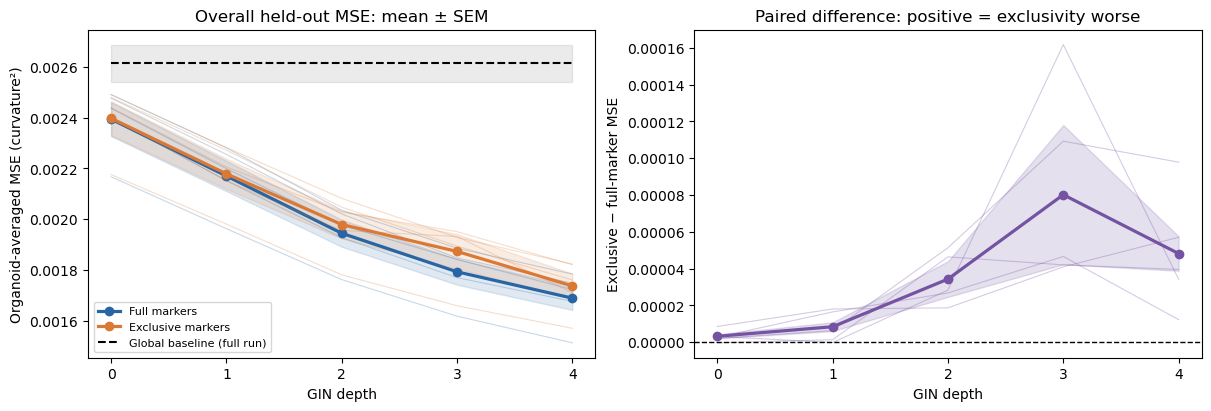

,depth,full_mse,exclusive_mse,mean_difference,n_organoids,relative_change_percent
0,0,0.002394,0.002397,0.000003,869,0.136124
1,1,0.002170,0.002179,0.000008,869,0.389409
2,2,0.001945,0.001979,0.000034,869,1.766949
3,3,0.001793,0.001873,0.000080,869,4.473053
4,4,0.001689,0.001738,0.000048,869,2.854221


In [4]:
parts = []
for label, run in runs.items():
    frame = pd.read_csv(run.directory / 'validation_mse.csv')
    frame = frame[frame.depth.isin(DEPTHS)].copy()
    frame['encoding'] = label
    parts.append(frame)
scores = pd.concat(parts, ignore_index=True)
keys = ['organoid_str', 'fold', 'seed', 'depth', 'hidden_dim', 'name', 'subset', 'signal']
paired = parts[0].merge(parts[1], on=keys, suffixes=('_full', '_exclusive'), validate='one_to_one')
assert len(paired) == len(parts[0]) == len(parts[1])
paired['mse_difference'] = paired.mse_exclusive - paired.mse_full
summary = organoid_mse_summary(scores, ['encoding', 'depth'])
difference_summary = organoid_mse_summary(paired, 'depth', value='mse_difference')
comparison = paired.groupby('depth').agg(full_mse=('mse_full', 'mean'), exclusive_mse=('mse_exclusive', 'mean'),
    mean_difference=('mse_difference', 'mean'), n_organoids=('organoid_str', 'nunique')).reset_index()
comparison['relative_change_percent'] = 100 * comparison.mean_difference / comparison.full_mse
fold_comparison = paired.groupby(['fold', 'depth']).agg(full_mse=('mse_full', 'mean'),
    exclusive_mse=('mse_exclusive', 'mean'), mean_difference=('mse_difference', 'mean')).reset_index()
for filename, frame in [('overall_scores', scores), ('paired_organoid_scores', paired), ('overall_summary', summary),
                         ('paired_difference_summary', difference_summary), ('comparison', comparison), ('fold_comparison', fold_comparison)]:
    frame.to_csv(OUTPUT_DIR / f'{filename}.csv', index=False)
COLORS = {'Full markers': '#2765a5', 'Exclusive markers': '#db7934'}

def plot_scores(ax, frame, *, show_baseline=True):
    for label, group in frame.groupby('encoding', sort=False):
        color = COLORS[label]
        for _, fold in group.groupby('fold'):
            curve = fold.groupby('depth').mse.mean().sort_index()
            ax.plot(curve.index, curve, color=color, alpha=.25, lw=.8)
        curve = organoid_mse_summary(group, 'depth').sort_values('depth')
        ax.plot(curve.depth, curve['mean'], 'o-', color=color, lw=2.3, label=label)
        ax.fill_between(curve.depth, curve['mean']-curve['sem'], curve['mean']+curve['sem'], color=color, alpha=.14)
    if show_baseline:
        baseline = organoid_mse_summary(frame[frame.encoding == 'Full markers'], 'depth', value='baseline_mse').sort_values('depth')
        ax.plot(baseline.depth, baseline['mean'], '--', color='black', label='Global baseline (full run)')
        ax.fill_between(baseline.depth, baseline['mean']-baseline['sem'], baseline['mean']+baseline['sem'], color='black', alpha=.08)
    ax.set(xlabel='GIN depth', ylabel='Organoid-averaged MSE (curvature²)', xticks=DEPTHS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
plot_scores(axes[0], scores)
axes[0].set_title('Overall held-out MSE: mean ± SEM')
axes[0].legend(fontsize=8)
for _, fold in fold_comparison.groupby('fold'):
    axes[1].plot(fold.depth, fold.mean_difference, color='#7454a2', alpha=.3, lw=.8)
d = difference_summary.sort_values('depth')
axes[1].plot(d.depth, d['mean'], 'o-', color='#7454a2', lw=2.3)
axes[1].fill_between(d.depth, d['mean']-d['sem'], d['mean']+d['sem'], color='#7454a2', alpha=.18)
axes[1].axhline(0, color='black', ls='--', lw=1)
axes[1].set(xlabel='GIN depth', ylabel='Exclusive − full-marker MSE', xticks=DEPTHS,
    title='Paired difference: positive = exclusivity worse')
fig.savefig(OUTPUT_DIR / 'overall_mse.png', dpi=180, bbox_inches='tight')
plt.show()
display(comparison.round(7))

## Regional validation on identical cells

Use the region assignments saved by the exclusive training notebook, derived from original graph/mesh annotations rather than another biological experiment. Qualified crypts use s<0.8, qualified necks 0.8≤s≤1.2, and their villus proxy s>1.2, matching the current training notebook. Unqualified crypt territories and organoids without detected crypts remain separate. These definitions are unchanged for the comparison and do not use exclusive fate assignments.

Restore each model and apply it to its own saved validation inputs. Check that region-weighted errors reproduce the saved overall MSE. The baseline shown is the full-marker run's global-only baseline; any numerical differences between the separately fitted baselines are recorded above.

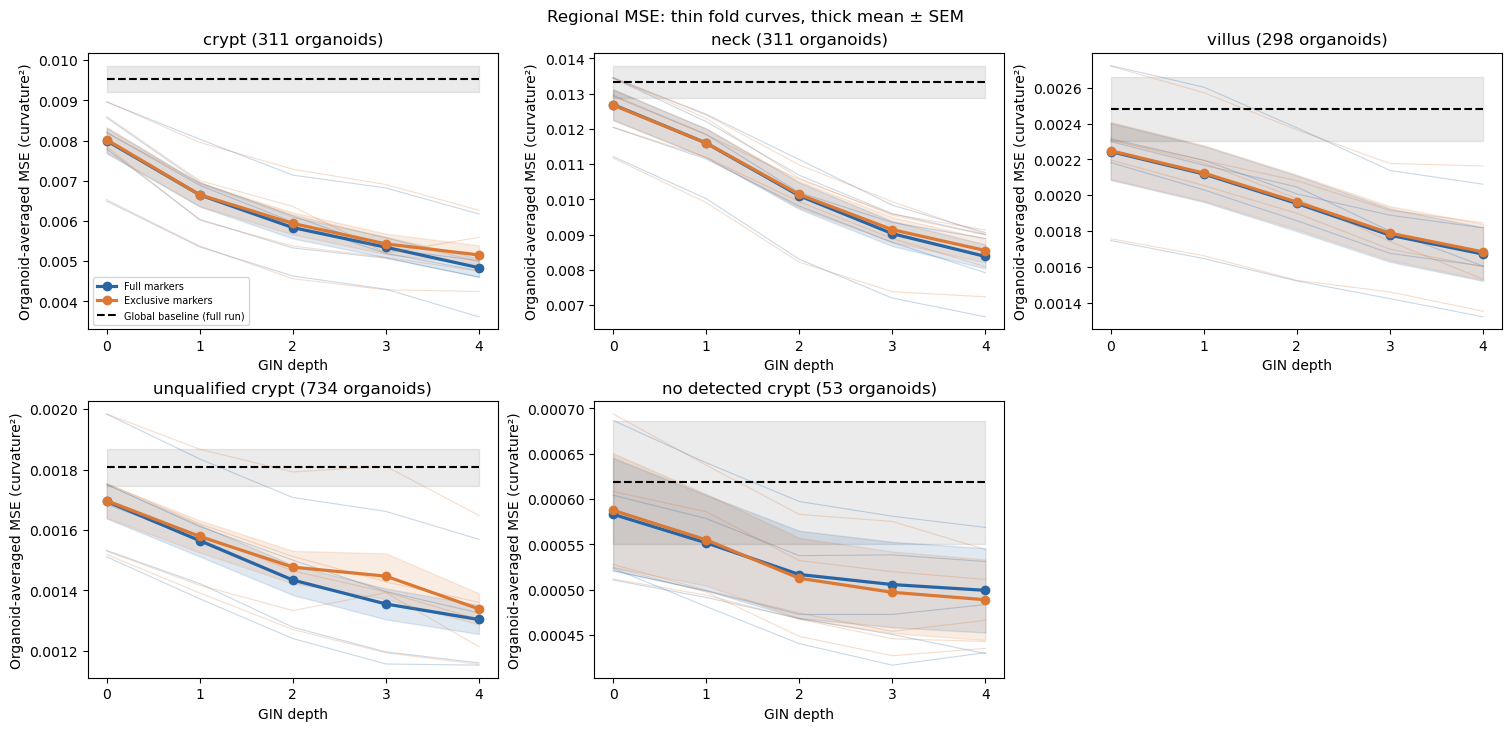

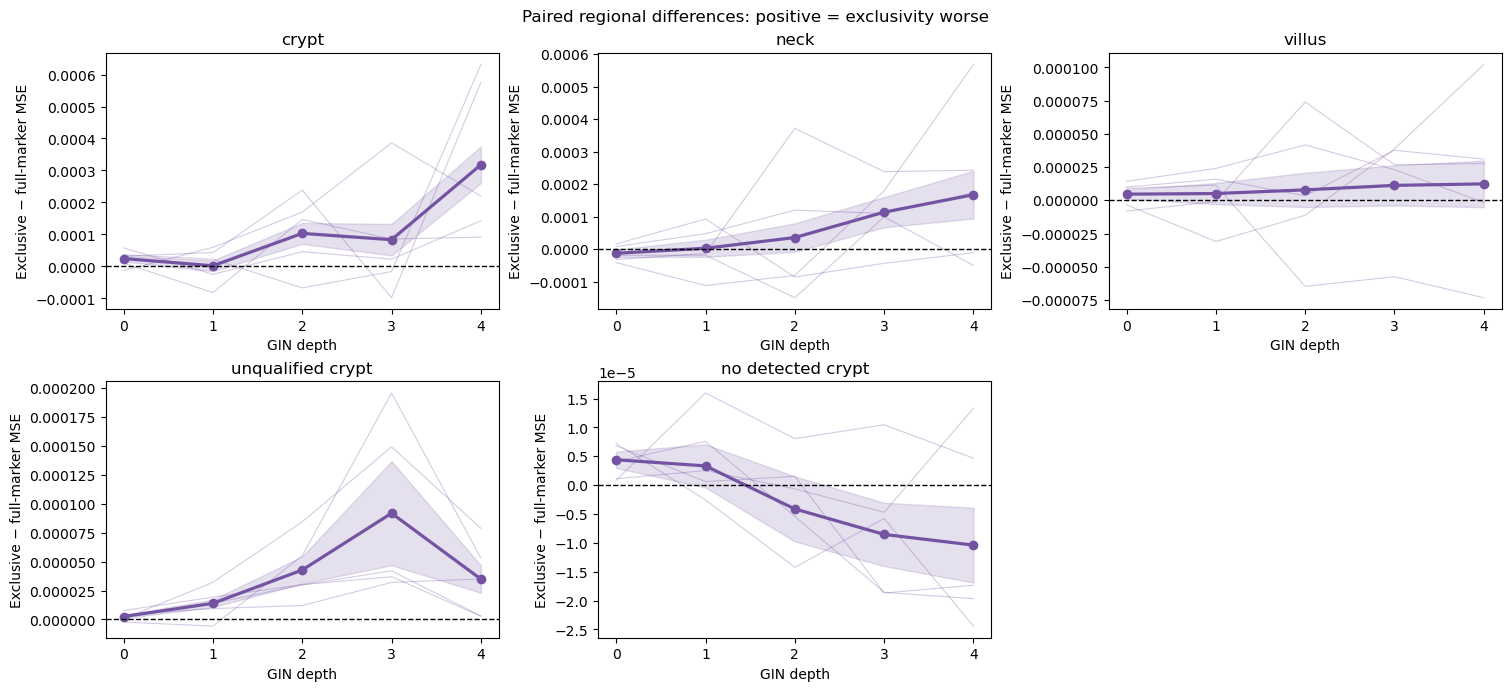

In [5]:
annotation_path = EXCLUSIVE_RUN / 'regional_evaluation/node_regions.csv.gz'
annotations = pd.read_csv(annotation_path)
region_settings = json.loads((EXCLUSIVE_RUN / 'regional_evaluation/settings.json').read_text())
(OUTPUT_DIR / 'region_settings.json').write_text(json.dumps(region_settings, indent=2))
regional_path = OUTPUT_DIR / 'regional_scores.csv'
if RUN_INFERENCE:
    regional_parts = []
    for label, run in runs.items():
        for record in run.records[run.records.depth.isin(DEPTHS)].sort_values(['fold', 'depth']).to_dict('records'):
            selected = run.select(record['key'], device=DEVICE)
            predictions = prediction_table(selected, device=DEVICE)
            check_scores = predictions.groupby('organoid_str').squared_error.mean()
            saved_scores = scores[(scores.encoding == label) & (scores.key == record['key'])].set_index('organoid_str').mse
            assert set(check_scores.index) == set(saved_scores.index)
            np.testing.assert_allclose(check_scores.loc[saved_scores.index], saved_scores, rtol=2e-4, atol=1e-8)
            frame = regional_mse(predictions, annotations)
            for column in ('key', 'fold', 'seed', 'depth', 'name', 'hidden_dim'):
                frame[column] = record[column]
            frame['encoding'] = label
            regional_parts.append(frame)
            print(f"Evaluated {label}: fold {record['fold']}, depth {record['depth']}")
            del selected, predictions
        run._data_cache.clear()
        gc.collect()
    regional_scores = pd.concat(regional_parts, ignore_index=True)
    regional_scores.to_csv(regional_path, index=False)
else:
    regional_scores = pd.read_csv(regional_path)
region_summary = organoid_mse_summary(regional_scores, ['encoding', 'region', 'depth'])
region_summary.to_csv(OUTPUT_DIR / 'regional_summary.csv', index=False)
region_keys = ['organoid_str', 'fold', 'seed', 'depth', 'region', 'name', 'hidden_dim']
regional_paired = regional_scores[regional_scores.encoding == 'Full markers'].merge(
    regional_scores[regional_scores.encoding == 'Exclusive markers'], on=region_keys,
    suffixes=('_full', '_exclusive'), validate='one_to_one')
assert len(regional_paired)*2 == len(regional_scores)
assert (regional_paired.n_cells_full == regional_paired.n_cells_exclusive).all()
regional_paired['mse_difference'] = regional_paired.mse_exclusive - regional_paired.mse_full
regional_paired.to_csv(OUTPUT_DIR / 'regional_paired_scores.csv', index=False)
region_order = [r for r in ['crypt', 'neck', 'villus', 'unqualified_crypt', 'no_detected_crypt', 'annotation_unavailable']
                if r in regional_scores.region.unique()]
assert set(region_order) == set(regional_scores.region.unique())
fig, axes = plt.subplots(int(np.ceil(len(region_order)/3)), 3,
                         figsize=(15, 3.6*int(np.ceil(len(region_order)/3))), squeeze=False, layout='constrained')
for ax, region in zip(axes.flat, region_order):
    frame = regional_scores[regional_scores.region == region]
    plot_scores(ax, frame)
    ax.set_title(f"{region.replace('_', ' ')} ({frame.organoid_str.nunique()} organoids)")
for ax in list(axes.flat)[len(region_order):]:
    ax.set_visible(False)
axes.flat[0].legend(fontsize=7)
fig.suptitle('Regional MSE: thin fold curves, thick mean ± SEM')
fig.savefig(OUTPUT_DIR / 'regional_mse.png', dpi=180, bbox_inches='tight')
plt.show()
fig, axes = plt.subplots(int(np.ceil(len(region_order)/3)), 3,
                         figsize=(15, 3.4*int(np.ceil(len(region_order)/3))), squeeze=False, layout='constrained')
for ax, region in zip(axes.flat, region_order):
    frame = regional_paired[regional_paired.region == region]
    for _, fold in frame.groupby('fold'):
        curve = fold.groupby('depth').mse_difference.mean().sort_index()
        ax.plot(curve.index, curve, color='#7454a2', alpha=.3, lw=.8)
    curve = organoid_mse_summary(frame, 'depth', value='mse_difference').sort_values('depth')
    ax.plot(curve.depth, curve['mean'], 'o-', color='#7454a2', lw=2.3)
    ax.fill_between(curve.depth, curve['mean']-curve['sem'], curve['mean']+curve['sem'], color='#7454a2', alpha=.18)
    ax.axhline(0, color='black', ls='--', lw=1)
    ax.set(title=region.replace('_', ' '), xlabel='GIN depth', ylabel='Exclusive − full-marker MSE', xticks=DEPTHS)
for ax in list(axes.flat)[len(region_order):]:
    ax.set_visible(False)
fig.suptitle('Paired regional differences: positive = exclusivity worse')
fig.savefig(OUTPUT_DIR / 'regional_differences.png', dpi=180, bbox_inches='tight')
plt.show()

## Interpretation

Read the paired differences alongside their individual-fold curves. Exclusivity removes coexpression information, so a loss of accuracy would quantify its predictive value under these fixed settings, not prove that coexpressed markers cause curvature. Conversely, similar performance would support exclusive identities as a useful simplification for this model and cohort.

The baseline and global inputs are retained exactly as configured in the training notebook. Early stopping uses the outer validation set in both runs, as in the existing workflow; this is a matched validation comparison, not an independent final test. Existing cohort-level outlier preprocessing is deliberately preserved for comparability.

In [6]:
depth2 = comparison[comparison.depth == 2]
if not depth2.empty:
    row = depth2.iloc[0]
    fold_deltas = fold_comparison[fold_comparison.depth == 2].mean_difference
    print(f"Depth 2: full MSE={row.full_mse:.7f}, exclusive MSE={row.exclusive_mse:.7f}; relative change {row.relative_change_percent:+.2f}%.")
    print(f"Exclusive has higher MSE in {(fold_deltas > 0).sum()}/{len(fold_deltas)} folds.")
print('Saved comparison figures, input checks and tables:', OUTPUT_DIR)


Depth 2: full MSE=0.0019448, exclusive MSE=0.0019792; relative change +1.77%.
Exclusive has higher MSE in 5/5 folds.
Saved comparison figures, input checks and tables: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/gin_depth_training/scMultiplexpaper_exclusive_20261006_110205/analysis/fate_encoding_comparison


## Measured marker restoration: aligned versus restored exclusive inputs

Compare the existing seven-marker exclusive GINs against GINs trained on the separate restored dataset, with the same hyperparameters, five folds and seeds. Missing stains remain unmeasured in metadata and zero-filled in model inputs; no availability flag or experiment ID is supplied to the network. The new input width is nine because Mucin 2 and Glucagon are explicit channels. Restoring these markers can also change the winning identity among the old channels when exclusivity is reapplied.

Check identical physical and transformed targets, global inputs, baselines, graph edges and memberships. Verify that the unstained experiment has unchanged old channels and zero new channels. Counts below refer to final exclusive identities, not every originally positive stain.

The additional channels change the first-layer parameterization and seeded random initialization. One seed per fold does not isolate encoding effects from training variability. Moreover, the restored channels can reveal experiment membership indirectly, so this remains a partially observed-panel comparison rather than validated marker imputation.

In [7]:
restored_run = AnalysisRun(RESTORED_RUN)
assert (RESTORED_RUN / 'complete.json').is_file(), 'Restored training run is incomplete.'
restored_diff = {k:[exclusive.settings.get(k), restored_run.settings.get(k)]
    for k in exclusive.settings.keys() | restored_run.settings.keys()
    if exclusive.settings.get(k) != restored_run.settings.get(k)}
assert set(restored_diff) <= {'tag', 'dataset'}, restored_diff
assert exclusive.settings['exclusive_markers'] and restored_run.settings['exclusive_markers']
assert json.loads((RESTORED_RUN / 'splits.json').read_text()) == memberships[1]
assert exclusive.records[grid_columns].sort_values(grid_columns).reset_index(drop=True).equals(
    restored_run.records[grid_columns].sort_values(grid_columns).reset_index(drop=True))
RESTORED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
raw_aligned = load_bundle(EXCLUSIVE_RUN / 'cohort')
raw_restored = load_bundle(RESTORED_RUN / 'cohort')
aligned_names = raw_aligned['all_marker_names']
restored_names = raw_restored['all_marker_names']
assert restored_names == aligned_names + ['Mucin 2', 'Glucagon']
assert set(raw_aligned['raw_graphs']) == set(raw_restored['raw_graphs'])
cohort_rows = []
for organoid, original in raw_aligned['raw_graphs'].items():
    revised = raw_restored['raw_graphs'][organoid]
    assert torch.equal(original.y, revised.y) and torch.equal(original.edge_index, revised.edge_index)
    assert bool((revised.x.sum(dim=1) <= 1).all())
    dataset = str(original.meta['dataset'])
    assert dataset == str(revised.meta['dataset']) and dataset in {'20250929','20251201'}
    availability = revised.meta['marker_measurement_available']
    for marker in ['Mucin 2', 'Glucagon']:
        assert bool(availability[marker]) == (dataset == '20250929')
    if dataset == '20251201':
        assert torch.equal(original.x, revised.x[:, :len(aligned_names)])
        assert not revised.x[:, len(aligned_names):].any()
    cohort_rows.append(dict(organoid_str=organoid, dataset=dataset, n_cells=len(original.x),
        changed_cells=int((original.x != revised.x[:, :len(aligned_names)]).any(dim=1).sum()),
        mucin_cells=int(revised.x[:,restored_names.index('Mucin 2')].sum()),
        glucagon_cells=int(revised.x[:,restored_names.index('Glucagon')].sum())))
restored_cohort = pd.DataFrame(cohort_rows)
restored_cohort.to_csv(RESTORED_OUTPUT_DIR / 'cohort_checks.csv',index=False)
del raw_aligned, raw_restored
restored_checks=[]
for fold in sorted(exclusive.records.fold.unique()):
    inputs=[load_bundle(run.directory / run.records.loc[run.records.fold==fold,'input_bundle'].iloc[0])
            for run in (exclusive,restored_run)]
    for role in ('train','val'):
        left,right=[v['groups'][role] for v in inputs]
        assert len(left)==len(right)
        for a,b in zip(left,right):
            assert a.organoid_str==b.organoid_str
            for attr in ('y','global_feat','edge_index'):
                torch.testing.assert_close(getattr(a,attr),getattr(b,attr),rtol=0,atol=0)
            np.testing.assert_array_equal(inputs[0]['baseline_predictions'][a.organoid_str],inputs[1]['baseline_predictions'][a.organoid_str])
            np.testing.assert_array_equal(inputs[0]['baseline_offsets'][a.organoid_str],inputs[1]['baseline_offsets'][a.organoid_str])
    restored_checks.append(dict(fold=int(fold),same_targets_globals_edges_baseline=True,
        train_organoids=len(inputs[0]['groups']['train']),validation_organoids=len(inputs[0]['groups']['val'])))
    del inputs
pd.DataFrame(restored_checks).to_csv(RESTORED_OUTPUT_DIR/'fold_checks.csv',index=False)
(RESTORED_OUTPUT_DIR/'settings.json').write_text(json.dumps(dict(aligned_run=str(EXCLUSIVE_RUN),
    restored_run=str(RESTORED_RUN),depths=DEPTHS,settings_differences=restored_diff,
    aligned_markers=aligned_names,restored_markers=restored_names),indent=2))
display(restored_cohort.groupby('dataset').agg(organoids=('organoid_str','size'),cells=('n_cells','sum'),
    changed_existing_channels=('changed_cells','sum'),mucin_cells=('mucin_cells','sum'),glucagon_cells=('glucagon_cells','sum')))
print('All restored-versus-aligned fold, target, baseline and feature checks passed.')

,organoids,cells,changed_existing_channels,mucin_cells,glucagon_cells
dataset,,,,,
20250929,675,316161,4470,4822,135
20251201,194,103581,0,0,0


All restored-versus-aligned fold, target, baseline and feature checks passed.


### Overall and experiment-specific MSE

Pair every restored model with its aligned-exclusive counterpart at the same depth, width, fold and seed. Average cell squared errors within each organoid, then give organoids equal weight. The overall result is therefore weighted by the number of organoids in each experiment, not the simple average of the two experiment-specific means.

Thin lines show individual folds; thick lines show means across held-out organoids with ±1 SEM bands. The second figure shows paired differences: positive means restoration worsens MSE. These bands describe conditional organoid variation, not uncertainty from repeated training seeds. The baseline is identical in both runs.

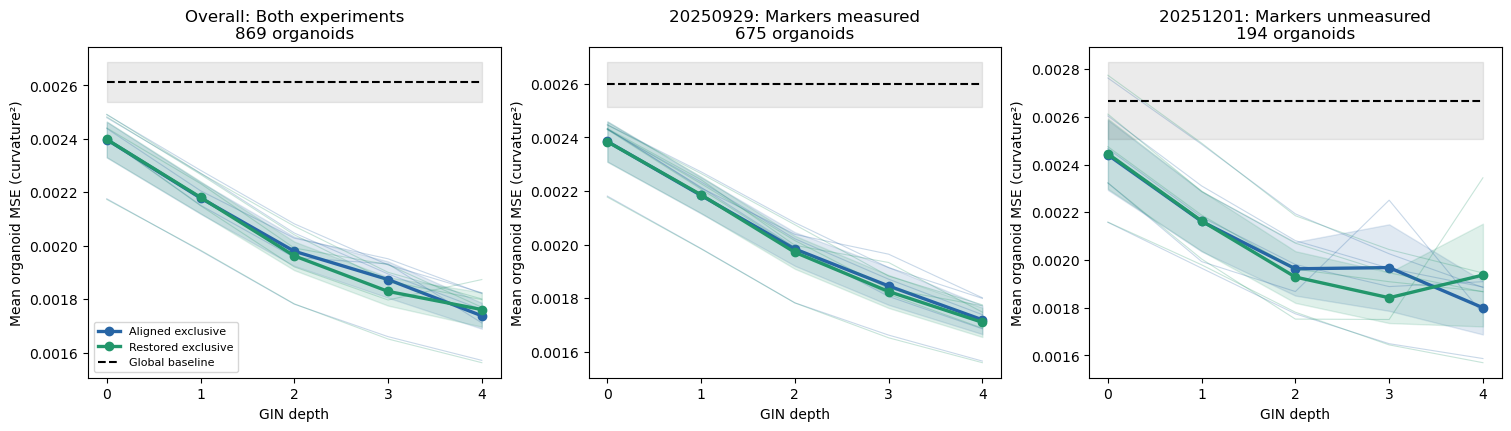

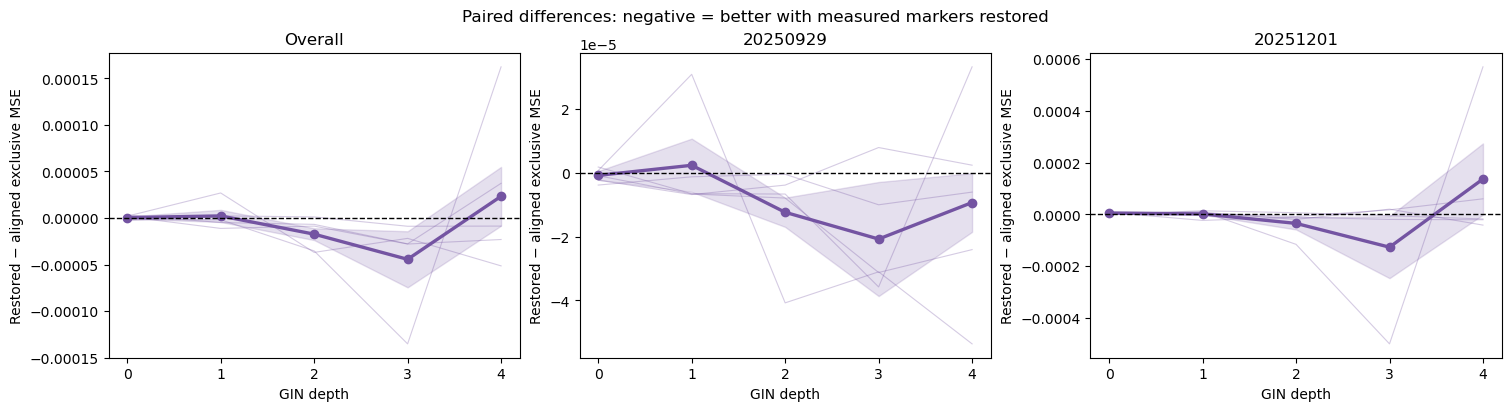

,scope,depth,aligned_mse,restored_mse,relative_change_percent,improved_folds,total_folds
0,Overall,0,0.002397,0.002398,0.020206,2,5
1,Overall,1,0.002179,0.002181,0.104022,3,5
2,Overall,2,0.001979,0.001962,-0.875534,4,5
3,Overall,3,0.001873,0.001829,-2.367865,5,5
4,Overall,4,0.001738,0.001761,1.343264,3,5
5,20250929,0,0.002385,0.002384,-0.033232,3,5
6,20250929,1,0.002184,0.002186,0.108375,4,5
7,20250929,2,0.001984,0.001972,-0.623200,5,5
8,20250929,3,0.001846,0.001825,-1.123878,4,5
9,20250929,4,0.001720,0.001710,-0.541224,3,5


Saved restored-marker comparison: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/gin_depth_training/scMultiplexpaper_exclusive_restored_20261006_131114/analysis/fate_encoding_comparison


In [8]:
restored_parts=[]
for label,run in [('Aligned exclusive',exclusive),('Restored exclusive',restored_run)]:
    f=pd.read_csv(run.directory/'validation_mse.csv')
    f=f[f.depth.isin(DEPTHS)].copy()
    f['encoding']=label
    f=f.merge(restored_cohort[['organoid_str','dataset']],on='organoid_str',validate='many_to_one')
    assert not f.dataset.isna().any()
    restored_parts.append(f)
restored_scores=pd.concat(restored_parts,ignore_index=True)
restored_pairs=restored_parts[0].merge(restored_parts[1],on=keys+['dataset'],
    suffixes=('_aligned','_restored'),validate='one_to_one')
assert len(restored_pairs)==len(restored_parts[0])==len(restored_parts[1])
assert (restored_pairs.n_cells_aligned==restored_pairs.n_cells_restored).all()
np.testing.assert_allclose(restored_pairs.baseline_mse_aligned,restored_pairs.baseline_mse_restored,rtol=0,atol=1e-14)
restored_pairs['mse_difference']=restored_pairs.mse_restored-restored_pairs.mse_aligned
restored_scores.to_csv(RESTORED_OUTPUT_DIR/'scores.csv',index=False)
restored_pairs.to_csv(RESTORED_OUTPUT_DIR/'paired_organoid_scores.csv',index=False)
comparison_rows=[]
fold_rows=[]
for scope in ['Overall','20250929','20251201']:
    f=restored_pairs if scope=='Overall' else restored_pairs[restored_pairs.dataset==scope]
    for depth,g in f.groupby('depth'):
        folds=g.groupby('fold').mse_difference.mean()
        comparison_rows.append(dict(scope=scope,depth=int(depth),organoids=g.organoid_str.nunique(),
            aligned_mse=g.mse_aligned.mean(),restored_mse=g.mse_restored.mean(),
            mean_difference=g.mse_difference.mean(),paired_sem=g.mse_difference.sem(),
            relative_change_percent=100*(g.mse_restored.mean()/g.mse_aligned.mean()-1),
            improved_folds=int((folds<0).sum()),total_folds=len(folds)))
        for fold,part in g.groupby('fold'):
            fold_rows.append(dict(scope=scope,depth=int(depth),fold=int(fold),organoids=len(part),
                aligned_mse=part.mse_aligned.mean(),restored_mse=part.mse_restored.mean(),
                mean_difference=part.mse_difference.mean()))
restored_comparison=pd.DataFrame(comparison_rows)
restored_fold_comparison=pd.DataFrame(fold_rows)
restored_comparison.to_csv(RESTORED_OUTPUT_DIR/'comparison.csv',index=False)
restored_fold_comparison.to_csv(RESTORED_OUTPUT_DIR/'fold_comparison.csv',index=False)
restored_colors={'Aligned exclusive':'#2765a5','Restored exclusive':'#22966b'}
fig,axes=plt.subplots(1,3,figsize=(15,4.2),layout='constrained')
for ax,scope in zip(axes,['Overall','20250929','20251201']):
    f=restored_scores if scope=='Overall' else restored_scores[restored_scores.dataset==scope]
    for label,group in f.groupby('encoding',sort=False):
        for _,fold in group.groupby('fold'):
            curve=fold.groupby('depth').mse.mean().sort_index()
            ax.plot(curve.index,curve,color=restored_colors[label],alpha=.25,lw=.8)
        curve=organoid_mse_summary(group,'depth').sort_values('depth')
        ax.plot(curve.depth,curve['mean'],'o-',color=restored_colors[label],label=label,lw=2.4)
        ax.fill_between(curve.depth,curve['mean']-curve['sem'],curve['mean']+curve['sem'],color=restored_colors[label],alpha=.14)
    baseline=organoid_mse_summary(f[f.encoding=='Aligned exclusive'],'depth',value='baseline_mse').sort_values('depth')
    ax.plot(baseline.depth,baseline['mean'],'--',color='black',label='Global baseline')
    ax.fill_between(baseline.depth,baseline['mean']-baseline['sem'],baseline['mean']+baseline['sem'],color='black',alpha=.08)
    status={'Overall':'Both experiments','20250929':'Markers measured','20251201':'Markers unmeasured'}[scope]
    ax.set(title=f'{scope}: {status}\n{f.organoid_str.nunique()} organoids',xlabel='GIN depth',ylabel='Mean organoid MSE (curvature²)',xticks=DEPTHS)
axes[0].legend(fontsize=8)
fig.savefig(RESTORED_OUTPUT_DIR/'mse_by_experiment.png',dpi=180,bbox_inches='tight')
plt.show()
fig,axes=plt.subplots(1,3,figsize=(15,4),layout='constrained')
for ax,scope in zip(axes,['Overall','20250929','20251201']):
    f=restored_pairs if scope=='Overall' else restored_pairs[restored_pairs.dataset==scope]
    for _,fold in f.groupby('fold'):
        curve=fold.groupby('depth').mse_difference.mean().sort_index()
        ax.plot(curve.index,curve,color='#7454a2',alpha=.3,lw=.8)
    curve=organoid_mse_summary(f,'depth',value='mse_difference').sort_values('depth')
    ax.plot(curve.depth,curve['mean'],'o-',color='#7454a2',lw=2.4)
    ax.fill_between(curve.depth,curve['mean']-curve['sem'],curve['mean']+curve['sem'],color='#7454a2',alpha=.18)
    ax.axhline(0,color='black',ls='--',lw=1)
    ax.set(title=scope,xlabel='GIN depth',ylabel='Restored − aligned exclusive MSE',xticks=DEPTHS)
fig.suptitle('Paired differences: negative = better with measured markers restored')
fig.savefig(RESTORED_OUTPUT_DIR/'paired_differences_by_experiment.png',dpi=180,bbox_inches='tight')
plt.show()
display(restored_comparison[['scope','depth','aligned_mse','restored_mse','relative_change_percent','improved_folds','total_folds']].round(7))
print('Saved restored-marker comparison:',RESTORED_OUTPUT_DIR)

### What this comparison can tell us

Any performance change in 20250929 combines the newly measured identities with the reassignment of previously aligned-exclusive cells, especially Agr2. In 20251201 the input identities have not changed; performance can still change because the jointly trained predictor and its parameters have changed. An improvement in that experiment would not demonstrate successful recovery of its unmeasured markers.

Assess each depth separately and inspect fold consistency. The restored channels are specific to one staining experiment, and repeated-seed training would be needed before attributing small differences solely to fate encoding.

### Sensitivity to individual validation organoids

Large mean differences in a smaller experiment can be driven by a few organoids. Identify the largest absolute paired MSE changes without excluding or changing any scores. The signed contribution is the organoid's MSE difference divided by the sum of differences in that experiment at that depth; it can exceed 100% when other organoids partly offset it. This is a descriptive diagnostic, not an exclusion rule.

In [9]:
contributors=[]
for (dataset,depth),group in restored_pairs.groupby(['dataset','depth']):
    net=group.mse_difference.sum()
    largest=group.loc[group.mse_difference.abs().nlargest(3).index]
    for rank,(_,row) in enumerate(largest.iterrows(),1):
        contributors.append(dict(dataset=dataset,depth=int(depth),rank=rank,organoid_str=row.organoid_str,
            fold=int(row.fold),aligned_mse=row.mse_aligned,restored_mse=row.mse_restored,
            mse_difference=row.mse_difference,share_of_net_difference=row.mse_difference/net if net!=0 else np.nan))
contributors=pd.DataFrame(contributors)
contributors.to_csv(RESTORED_OUTPUT_DIR/'largest_organoid_differences.csv',index=False)
display(contributors[(contributors.dataset=='20251201') & (contributors.depth.isin([2,3,4])) & (contributors['rank']==1)])

,dataset,depth,rank,organoid_str,fold,aligned_mse,restored_mse,mse_difference,share_of_net_difference
21,20251201,2,1,organoid_day4p5_B03_15,1,0.007054,0.002584,-0.004470,0.665907
24,20251201,3,1,organoid_day4p5_B03_15,1,0.030958,0.007757,-0.023201,0.945362
27,20251201,4,1,organoid_day4p5_B03_15,1,0.012300,0.038937,0.026637,1.002657


### Findings: measured marker restoration

All 25 restored-marker GINs completed on the same 869 organoids, five folds and seed 42 as the aligned-exclusive reference. Targets, globals, baselines and adjacency agree exactly; there are 675 organoids in the measured experiment and 194 in the unstained one.

| Depth | Overall MSE change | 20250929, measured | 20251201, unmeasured |
| --- | ---: | ---: | ---: |
| 0 | +0.02% | −0.03% | +0.20% |
| 1 | +0.10% | +0.11% | +0.09% |
| 2 | −0.88% | −0.62% | −1.76% |
| 3 | −2.37% | −1.12% | −6.43% |
| 4 | +1.34% | −0.54% | +7.61% |

Negative means better with measured markers restored. At depth 2, overall MSE is **0.0019792 → 0.0019619**. The measured experiment improves in all five folds, but by only **0.62%** on average. The overall improvement holds in four of five folds.

The apparent large changes in 20251201 at depths 3 and 4 are dominated by **day4p5_B03_15**: it accounts for about **95%** of the net depth-3 improvement and approximately all of the net depth-4 deterioration. Its MSE changes from **0.030958 → 0.007757** at depth 3, and **0.012300 → 0.038937** at depth 4. It remains included in all reported scores. These shifts should not be interpreted as broad improvements/deteriorations across the unstained experiment.

**Interpretation:** restoration yields a small predictive benefit in the measured experiment at depths 2–4, while performance remains broadly similar. The unstained experiment receives no recovered identities; its predictions change through pooled training of the expanded-input model. With a single initialization seed and a different input width, these results do not establish a large or robust general accuracy benefit from partial marker restoration.

## 20250929-only control: aligned versus restored exclusive fates

Train and validate solely on experiment 20250929, using the existing day4/day4p5/day4p5-more and sphericity≤0.93 filters. Compare seven aligned-exclusive channels with nine restored-exclusive channels. The experiment filter runs before target cleanup, splitting, baseline fitting and training; 20251201 contributes no fitted statistics or inputs.

Both runs use five identical freshly generated folds (seed 42), depths 0–4, width 128 and the same hyperparameters. All 675 organoids have measured Mucin 2 and Glucagon. Unlike pooled training, marker presence cannot identify which of these two experiments a cell came from: all cells are from the same one. This still does not establish causal marker effects or prove that the earlier pooled model ignored experiment identity.

Because folds and cohort-level outlier thresholds differ from the earlier pooled experiment, compare the two runs below directly with each other. Target cleanup follows the workhorse notebook and early stopping uses the validation folds; these are matched validation comparisons, not an untouched final test.

In [10]:
single_runs = {'Aligned exclusive':AnalysisRun(SINGLE_ALIGNED_RUN), 'Restored exclusive':AnalysisRun(SINGLE_RESTORED_RUN)}
single_aligned, single_restored = single_runs.values()
SINGLE_OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
for run in single_runs.values():
    assert (run.directory/'complete.json').is_file()
    assert run.settings['measurement_datasets']==['20250929']
    assert run.settings['exclusive_markers'] is True
single_diff={k:[single_aligned.settings.get(k),single_restored.settings.get(k)]
    for k in single_aligned.settings.keys() | single_restored.settings.keys()
    if single_aligned.settings.get(k)!=single_restored.settings.get(k)}
assert set(single_diff)<= {'tag','dataset'},single_diff
single_splits=[json.loads((run.directory/'splits.json').read_text()) for run in single_runs.values()]
assert single_splits[0]==single_splits[1]
assert single_aligned.records[grid_columns].sort_values(grid_columns).reset_index(drop=True).equals(
    single_restored.records[grid_columns].sort_values(grid_columns).reset_index(drop=True))
raw=[load_bundle(run.directory/'cohort') for run in single_runs.values()]
assert raw[1]['all_marker_names']==raw[0]['all_marker_names']+['Mucin 2','Glucagon']
assert raw[0]['outlier_info']['thresholds']==raw[1]['outlier_info']['thresholds']
assert set(raw[0]['raw_graphs'])==set(raw[1]['raw_graphs'])
for organoid,g in raw[0]['raw_graphs'].items():
    h=raw[1]['raw_graphs'][organoid]
    assert str(g.meta['dataset'])==str(h.meta['dataset'])=='20250929'
    assert torch.equal(g.y,h.y) and torch.equal(g.edge_index,h.edge_index)
    assert (g.x.sum(dim=1)<=1).all() and (h.x.sum(dim=1)<=1).all()
    assert h.meta['marker_measurement_available']['Mucin 2'] and h.meta['marker_measurement_available']['Glucagon']
single_cohort_size=len(raw[0]['raw_graphs'])
single_thresholds=raw[0]['outlier_info']['thresholds']
del raw
single_checks=[]
for fold in sorted(single_aligned.records.fold.unique()):
    inputs=[load_bundle(run.directory/run.records.loc[run.records.fold==fold,'input_bundle'].iloc[0]) for run in single_runs.values()]
    baseline_difference=0.
    for role in ('train','val'):
        left,right=[v['groups'][role] for v in inputs]
        assert len(left)==len(right)
        for g,h in zip(left,right):
            assert g.organoid_str==h.organoid_str
            for attr in ('y','global_feat','edge_index'):
                torch.testing.assert_close(getattr(g,attr),getattr(h,attr),rtol=0,atol=0)
            np.testing.assert_array_equal(inputs[0]['baseline_offsets'][g.organoid_str],inputs[1]['baseline_offsets'][g.organoid_str])
            baseline_difference=max(baseline_difference,float(np.max(abs(inputs[0]['baseline_predictions'][g.organoid_str]-inputs[1]['baseline_predictions'][g.organoid_str]))))
    assert baseline_difference==0
    single_checks.append(dict(fold=int(fold),train_organoids=len(inputs[0]['groups']['train']),
        validation_organoids=len(inputs[0]['groups']['val']),same_targets_globals_edges_baseline=True))
    del inputs
pd.DataFrame(single_checks).to_csv(SINGLE_OUTPUT_DIR/'fold_checks.csv',index=False)
(SINGLE_OUTPUT_DIR/'settings.json').write_text(json.dumps(dict(aligned_run=str(SINGLE_ALIGNED_RUN),
    restored_run=str(SINGLE_RESTORED_RUN),settings_differences=single_diff,depths=DEPTHS,
    cohort_size=single_cohort_size,outlier_thresholds=single_thresholds),indent=2))
print(f'All comparison checks passed: {single_cohort_size} organoids exclusively from 20250929.')
display(pd.DataFrame(single_checks))

All comparison checks passed: 675 organoids exclusively from 20250929.


,fold,train_organoids,validation_organoids,same_targets_globals_edges_baseline
0,0,540,135,True
1,1,540,135,True
2,2,540,135,True
3,3,540,135,True
4,4,540,135,True


### MSE and paired differences at each depth

Each organoid receives equal weight. Thin curves show individual folds; thick curves show the overall mean, with ±1 SEM across organoids. The paired difference is restored minus aligned MSE, so negative indicates a benefit from the restored markers. Counts of improved folds and organoids are exported alongside the mean difference.

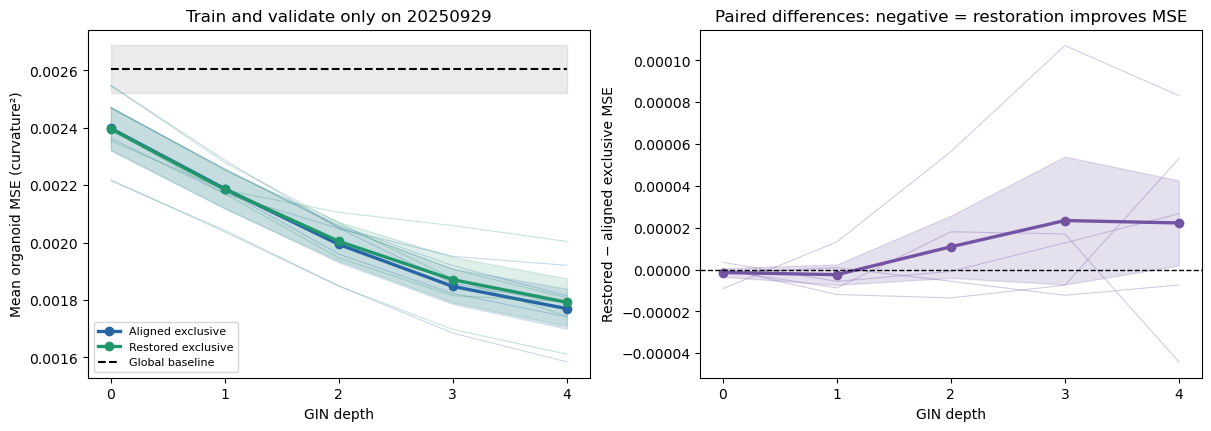

,depth,organoids,aligned_mse,restored_mse,mean_difference,paired_sem,relative_change_percent,improved_folds,total_folds,improved_organoids
0,0,675,0.002398,0.002396,-0.000001,0.000002,-0.057701,3,5,326
1,1,675,0.002188,0.002185,-0.000002,0.000005,-0.110444,3,5,382
2,2,675,0.001994,0.002005,0.000011,0.000015,0.547469,3,5,320
3,3,675,0.001847,0.001871,0.000023,0.000031,1.270384,2,5,352
4,4,675,0.001770,0.001792,0.000022,0.000020,1.260719,2,5,335


Saved within-experiment comparison: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/gin_depth_training/single20250929_exclusive_restored_20261006_134029/analysis/fate_encoding_comparison


In [11]:
single_parts=[]
for label,run in single_runs.items():
    f=pd.read_csv(run.directory/'validation_mse.csv')
    f=f[f.depth.isin(DEPTHS)].copy()
    f['encoding']=label
    single_parts.append(f)
single_scores=pd.concat(single_parts,ignore_index=True)
single_pairs=single_parts[0].merge(single_parts[1],on=keys,suffixes=('_aligned','_restored'),validate='one_to_one')
assert len(single_pairs)==len(single_parts[0])==len(single_parts[1])
assert (single_pairs.n_cells_aligned==single_pairs.n_cells_restored).all()
np.testing.assert_allclose(single_pairs.baseline_mse_aligned,single_pairs.baseline_mse_restored,rtol=0,atol=1e-14)
single_pairs['mse_difference']=single_pairs.mse_restored-single_pairs.mse_aligned
single_scores.to_csv(SINGLE_OUTPUT_DIR/'scores.csv',index=False)
single_pairs.to_csv(SINGLE_OUTPUT_DIR/'paired_organoid_scores.csv',index=False)
single_rows=[]
for depth,g in single_pairs.groupby('depth'):
    folds=g.groupby('fold').mse_difference.mean()
    single_rows.append(dict(depth=int(depth),organoids=g.organoid_str.nunique(),aligned_mse=g.mse_aligned.mean(),
        restored_mse=g.mse_restored.mean(),mean_difference=g.mse_difference.mean(),paired_sem=g.mse_difference.sem(),
        relative_change_percent=100*(g.mse_restored.mean()/g.mse_aligned.mean()-1),
        improved_folds=int((folds<0).sum()),total_folds=len(folds),improved_organoids=int((g.mse_difference<0).sum())))
single_comparison=pd.DataFrame(single_rows)
single_comparison.to_csv(SINGLE_OUTPUT_DIR/'comparison.csv',index=False)
single_fold_comparison=single_pairs.groupby(['depth','fold']).agg(aligned_mse=('mse_aligned','mean'),
    restored_mse=('mse_restored','mean'),mean_difference=('mse_difference','mean')).reset_index()
single_fold_comparison.to_csv(SINGLE_OUTPUT_DIR/'fold_comparison.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12,4.2),layout='constrained')
for label,group in single_scores.groupby('encoding',sort=False):
    color=restored_colors[label]
    for _,fold in group.groupby('fold'):
        curve=fold.groupby('depth').mse.mean().sort_index()
        axes[0].plot(curve.index,curve,color=color,alpha=.25,lw=.8)
    curve=organoid_mse_summary(group,'depth').sort_values('depth')
    axes[0].plot(curve.depth,curve['mean'],'o-',color=color,lw=2.4,label=label)
    axes[0].fill_between(curve.depth,curve['mean']-curve['sem'],curve['mean']+curve['sem'],color=color,alpha=.14)
baseline=organoid_mse_summary(single_scores[single_scores.encoding=='Aligned exclusive'],'depth',value='baseline_mse')
axes[0].plot(baseline.depth,baseline['mean'],'--',color='black',label='Global baseline')
axes[0].fill_between(baseline.depth,baseline['mean']-baseline['sem'],baseline['mean']+baseline['sem'],color='black',alpha=.08)
axes[0].set(title='Train and validate only on 20250929',xlabel='GIN depth',ylabel='Mean organoid MSE (curvature²)',xticks=DEPTHS)
axes[0].legend(fontsize=8)
for _,fold in single_fold_comparison.groupby('fold'):
    axes[1].plot(fold.depth,fold.mean_difference,color='#7454a2',alpha=.3,lw=.8)
curve=organoid_mse_summary(single_pairs,'depth',value='mse_difference').sort_values('depth')
axes[1].plot(curve.depth,curve['mean'],'o-',color='#7454a2',lw=2.4)
axes[1].fill_between(curve.depth,curve['mean']-curve['sem'],curve['mean']+curve['sem'],color='#7454a2',alpha=.18)
axes[1].axhline(0,color='black',ls='--',lw=1)
axes[1].set(title='Paired differences: negative = restoration improves MSE',xlabel='GIN depth',ylabel='Restored − aligned exclusive MSE',xticks=DEPTHS)
fig.savefig(SINGLE_OUTPUT_DIR/'single_dataset_comparison.png',dpi=180,bbox_inches='tight')
plt.show()
display(single_comparison.round(7))
contributors=[]
for depth,g in single_pairs.groupby('depth'):
    net=g.mse_difference.sum()
    for rank,(_,row) in enumerate(g.loc[g.mse_difference.abs().nlargest(5).index].iterrows(),1):
        contributors.append(dict(depth=int(depth),rank=rank,organoid_str=row.organoid_str,fold=int(row.fold),
            mse_aligned=row.mse_aligned,mse_restored=row.mse_restored,mse_difference=row.mse_difference,
            share_of_net_difference=row.mse_difference/net if net else np.nan))
pd.DataFrame(contributors).to_csv(SINGLE_OUTPUT_DIR/'largest_organoid_differences.csv',index=False)
print('Saved within-experiment comparison:',SINGLE_OUTPUT_DIR)

### Reading the within-experiment result

A benefit from restored markers here cannot be explained by recognizing 20250929 versus 20251201: the latter is absent from both fitting and validation. It would support predictive information in measured Mucin 2/Glucagon and the corresponding fate reassignment within the stained experiment. It would not establish a causal interaction, identify which restored marker supplies the benefit, or show that the pooled model did not use dataset cues.

Small differences remain subject to optimization variability, especially because adding two channels changes the input parameterization despite the shared seed. Fold curves and per-organoid paired differences help distinguish widespread gains from effects concentrated in a few samples.

### Findings from the completed 20250929-only control

**Restoring the measured markers does not provide a clear, consistent accuracy gain within this experiment.** Both exclusive encodings perform very similarly. All 50 GIN fits completed (two encodings × five depths × five folds), and all checks of matched membership, targets, graph edges, global features and baseline predictions passed.

| Depth | Aligned-exclusive MSE | Restored-exclusive MSE | Change with restoration | Improved folds |
| --- | ---: | ---: | ---: | ---: |
| 0 | 0.0023978 | 0.0023964 | -0.06% | 3/5 |
| 1 | 0.0021875 | 0.0021851 | -0.11% | 3/5 |
| 2 | 0.0019935 | 0.0020045 | +0.55% | 3/5 |
| 3 | 0.0018473 | 0.0018708 | +1.27% | 2/5 |
| 4 | 0.0017698 | 0.0017921 | +1.26% | 2/5 |

At depth 2, mean MSE changes from 0.0019935 to 0.0020045 (+0.55%); three of five folds and 320 of 675 organoids improve. The paired organoid mean difference is +0.00001091, with descriptive SEM 0.00001488. These bands condition on the fitted models and are not a formal retraining-uncertainty test.

The average difference is strongly affected by **organoid_day4p5-more_C01_51** in fold 3: its depth-2 MSE increases from 0.0138245 to 0.0236565. Its contribution is 133% of the net worsening, meaning the other organoids partially offset it. The same organoid accounts for 128% and 86% of net worsening at depths 3 and 4. It remains included in every reported score; this diagnostic does not establish a reason to exclude it.

This experiment prevents a cue distinguishing 20250929 from 20251201 because all fitting and validation data come from 20250929. It **does not prove** that the previous pooled model ignored such a cue, nor does the absence of a gain establish that Mucin 2/Glucagon are biologically uninformative. Their incremental benefit may be small relative to information already available in shared markers. Adding two input channels also changes model initialization and parameterization; a single seed does not isolate those effects from the encoding change.

The experiment selection was applied before outlier cleanup. These two runs use identical fresh within-experiment folds and identical cleanup thresholds, but those differ from the previous pooled runs. Compare the two current encodings directly; a pooled-versus-single MSE difference cannot be attributed solely to removing 20251201. As in the workhorse training setup, the held-out folds guide early stopping; they are validation data rather than an untouched final test set.
